In [5]:
import importlib
import miaw
import pandas as pd
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


In [94]:
# train-test data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(56000, 784) (56000, 10) (14000, 784) (14000, 10)


In [95]:
# Random test sample from Kaggle
test_url = 'https://drive.google.com/uc?id=1VwGTcs1guwJTnUHKdOkMgDUtuW18DbEp'
test_df = pd.read_csv(test_url)

y_test = test_df["label"].values 
X_test = test_df.drop(columns=["label"]).values
print(X_test.shape, y_test.shape)

(10000, 784) (10000,)


# Analysis of Parameters

### 1. Learning Rate

Val accuracy: 49.70%, Test accuracy: 50.84%


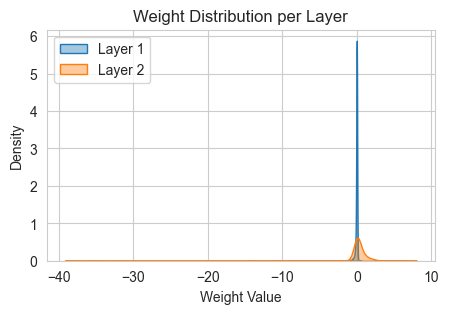

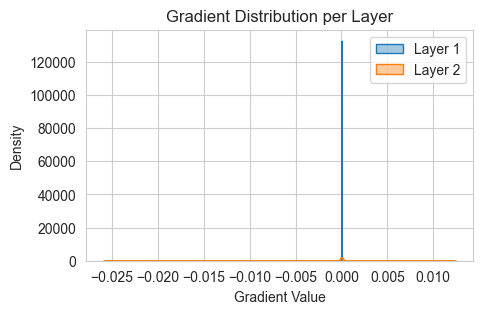

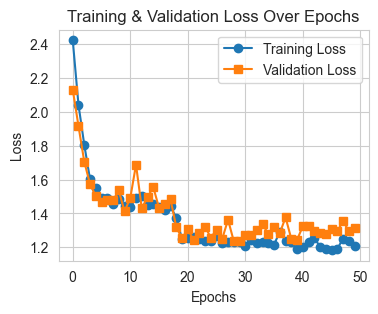

In [96]:
lr1_model = FFNN([784,64,10], ['relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = lr1_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.5, verbose=0)

lr_val_pred = lr1_model.predict(X_val)
lr_test_pred = lr1_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

lr1_model.plot_distribution([0,1,2,3], plot_type="weight")
lr1_model.plot_distribution([0,1,2,3], plot_type="gradient")
lr1_model.plot_loss_history(history)

lr1_model.save('./models/lr1.json')

Val accuracy: 92.42%, Test accuracy: 94.25%


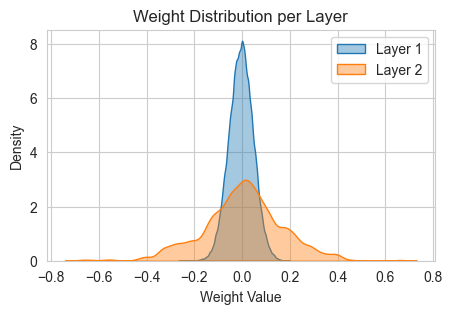

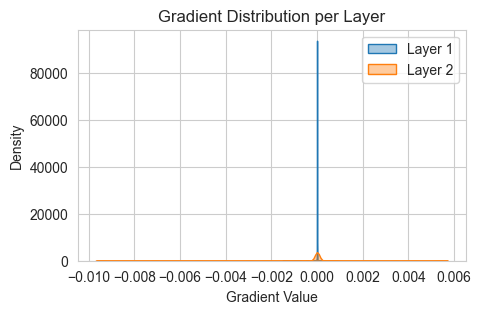

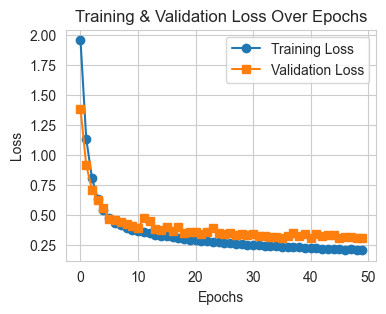

In [97]:
lr2_model = FFNN([784,64,10], ['relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = lr2_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)

lr_val_pred = lr2_model.predict(X_val)
lr_test_pred = lr2_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

lr2_model.plot_distribution([0,1,2,3], plot_type="weight")
lr2_model.plot_distribution([0,1,2,3], plot_type="gradient")
lr2_model.plot_loss_history(history)

lr2_model.save('./models/lr2.json')

Val accuracy: 89.69%, Test accuracy: 91.42%


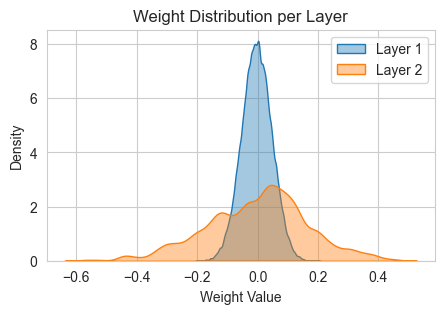

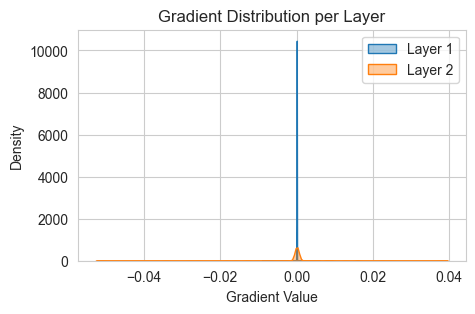

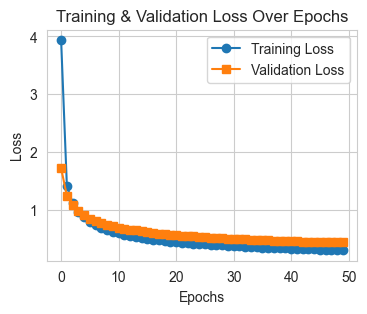

In [98]:
lr3_model = FFNN([784,64,10], ['relu','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

history = lr3_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.01, verbose=0)

lr_val_pred = lr3_model.predict(X_val)
lr_test_pred = lr3_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

lr3_model.plot_distribution([0,1,2,3], plot_type="weight")
lr3_model.plot_distribution([0,1,2,3], plot_type="gradient")
lr3_model.plot_loss_history(history)

lr3_model.save('./models/lr3.json')

### Weight Initialization

Val accuracy: 23.26%, Test accuracy: 23.25%


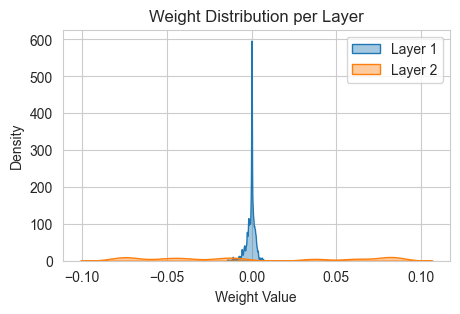

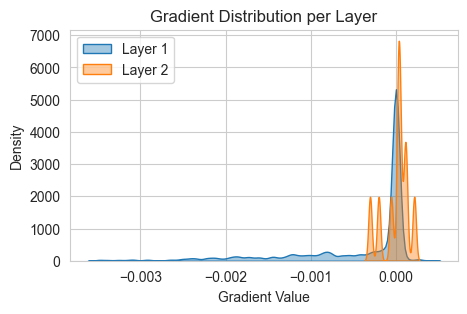

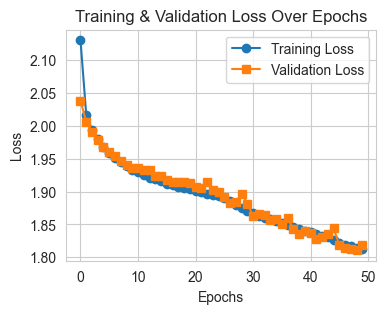

In [169]:
zero_weight_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='zero')

zero_weight_history = zero_weight_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = zero_weight_model.predict(X_val)
lr_test_pred = zero_weight_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

zero_weight_model.plot_distribution([0,1,2,3], plot_type="weight")
zero_weight_model.plot_distribution([0,1,2,3], plot_type="gradient")
zero_weight_model.plot_loss_history(zero_weight_history)

zero_weight_model.save('./models/zero.json')

Val accuracy: 75.61%, Test accuracy: 77.48%


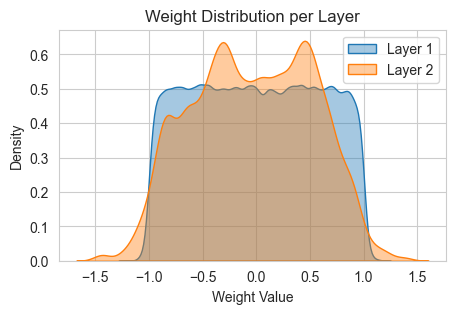

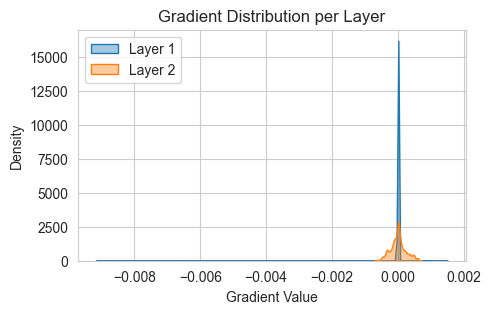

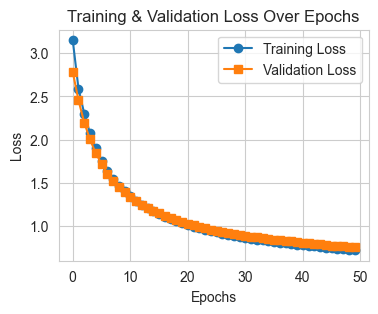

In [108]:
uniform_weight_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='uniform')

zero_weight_history = uniform_weight_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = uniform_weight_model.predict(X_val)
lr_test_pred = uniform_weight_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

uniform_weight_model.plot_distribution([0,1,2,3], plot_type="weight")
uniform_weight_model.plot_distribution([0,1,2,3], plot_type="gradient")
uniform_weight_model.plot_loss_history(zero_weight_history)

uniform_weight_model.save('./models/uniform.json')

Val accuracy: 67.23%, Test accuracy: 68.58%


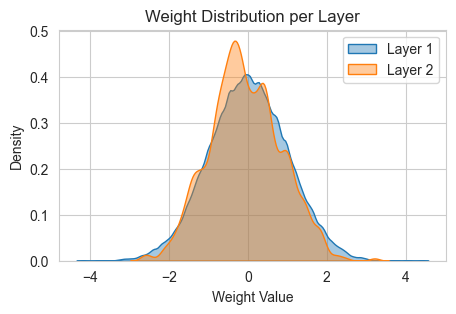

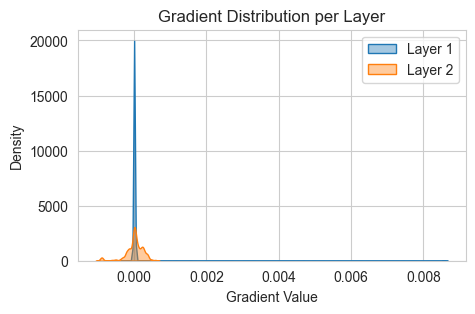

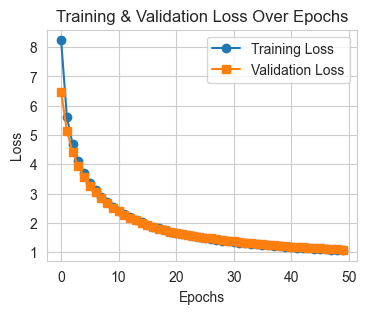

In [109]:
normal_weight_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='normal')

normal_weight_history = normal_weight_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = normal_weight_model.predict(X_val)
lr_test_pred = normal_weight_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

normal_weight_model.plot_distribution([0,1,2,3], plot_type="weight")
normal_weight_model.plot_distribution([0,1,2,3], plot_type="gradient")
normal_weight_model.plot_loss_history(normal_weight_history)

normal_weight_model.save('./models/normal.json')

Val accuracy: 92.80%, Test accuracy: 94.38%


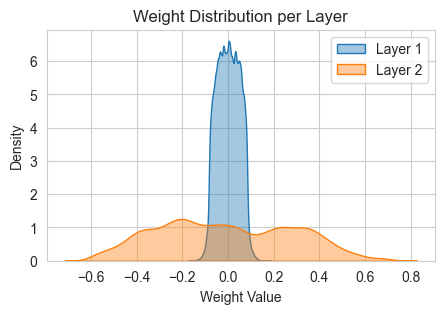

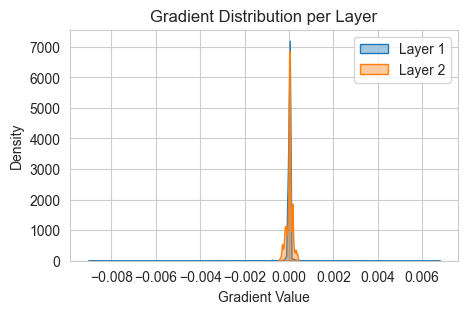

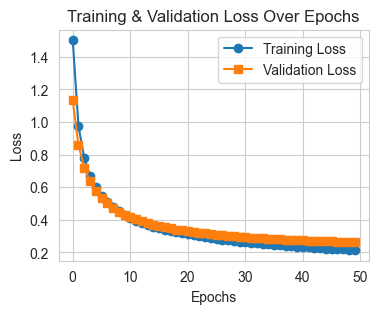

In [128]:
xavier_weight_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='xavier')

xavier_weight_history = xavier_weight_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = xavier_weight_model.predict(X_val)
lr_test_pred = xavier_weight_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

xavier_weight_model.plot_distribution([0,1,2,3], plot_type="weight")
xavier_weight_model.plot_distribution([0,1,2,3], plot_type="gradient")
xavier_weight_model.plot_loss_history(xavier_weight_history)

xavier_weight_model.save('./models/xavier.json')

Val accuracy: 92.41%, Test accuracy: 94.21%


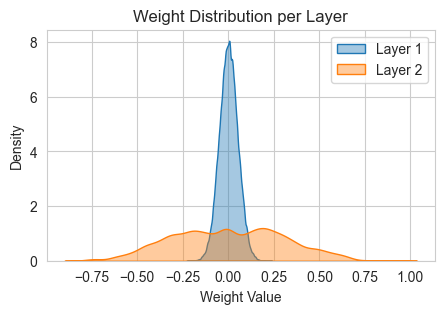

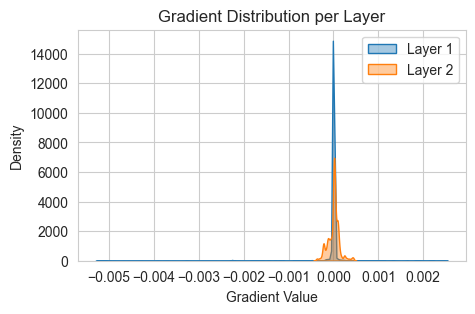

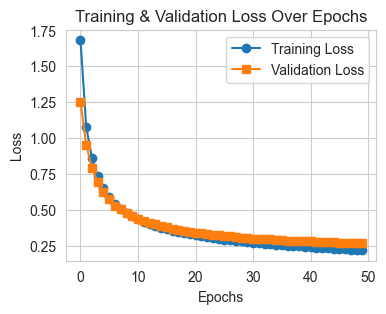

In [129]:
he_weight_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

he_weight_history = he_weight_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = he_weight_model.predict(X_val)
lr_test_pred = he_weight_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

he_weight_model.plot_distribution([0,1,2,3], plot_type="weight")
he_weight_model.plot_distribution([0,1,2,3], plot_type="gradient")
he_weight_model.plot_loss_history(he_weight_history)

he_weight_model.save('./models/he.json')

### 3. Regularization

Val accuracy: 92.28%, Test accuracy: 94.25%


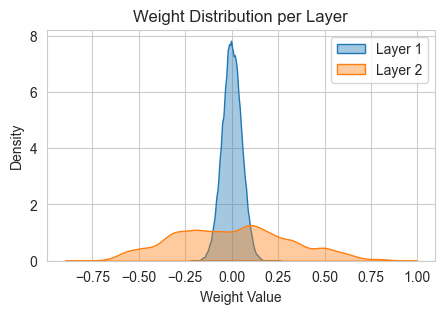

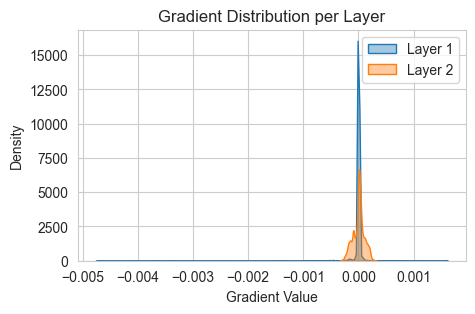

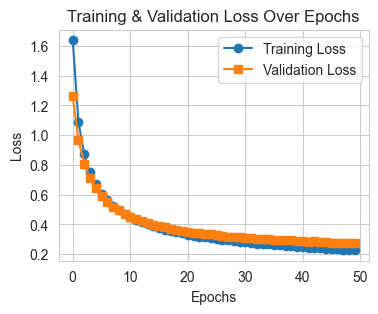

In [139]:
no_reg_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, weight_init='he')

no_reg_history = no_reg_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = no_reg_model.predict(X_val)
lr_test_pred = no_reg_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

no_reg_model.plot_distribution([0,1,2,3], plot_type="weight")
no_reg_model.plot_distribution([0,1,2,3], plot_type="gradient")
no_reg_model.plot_loss_history(no_reg_history)

no_reg_model.save('./models/noreg.json')

Val accuracy: 92.32%, Test accuracy: 94.42%


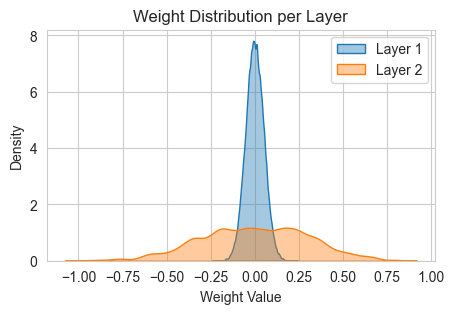

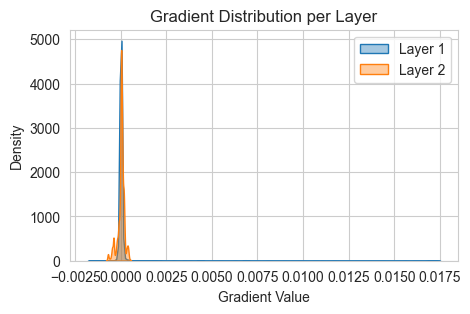

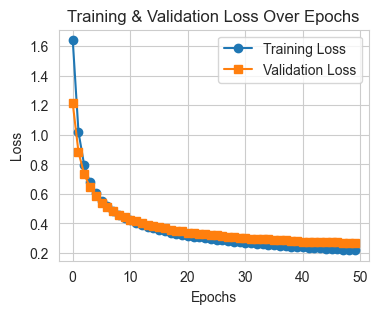

In [145]:
reg_l1_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l1", weight_init='he')

reg_l1_history = reg_l1_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = reg_l1_model.predict(X_val)
lr_test_pred = reg_l1_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

reg_l1_model.plot_distribution([0,1,2,3], plot_type="weight")
reg_l1_model.plot_distribution([0,1,2,3], plot_type="gradient")
reg_l1_model.plot_loss_history(reg_l1_history)

reg_l1_model.save('./models/regl1.json')

Val accuracy: 92.47%, Test accuracy: 94.68%


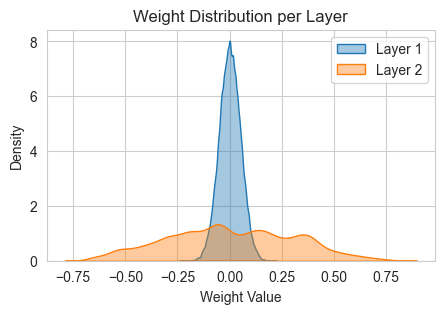

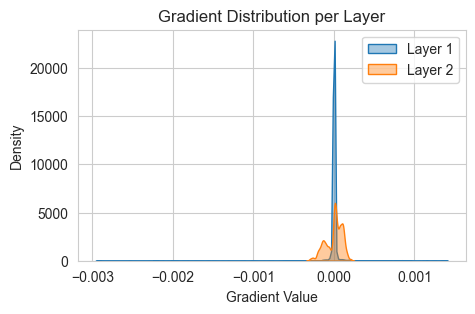

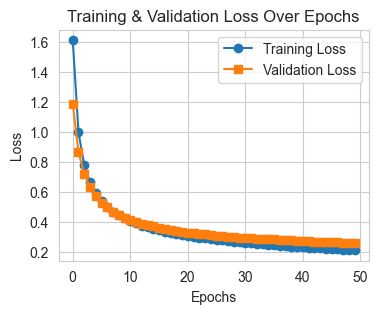

In [148]:
reg_l2_model = FFNN([784,64,10], ['sigmoid','softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

reg_l2_history = reg_l2_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)
lr_val_pred = reg_l2_model.predict(X_val)
lr_test_pred = reg_l2_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

reg_l2_model.plot_distribution([0,1,2,3], plot_type="weight")
reg_l2_model.plot_distribution([0,1,2,3], plot_type="gradient")
reg_l2_model.plot_loss_history(reg_l2_history)

reg_l2_model.save('./models/regl2.json')

### 4.RMSNORM

Val accuracy: 83.60%, Test accuracy: 84.40%


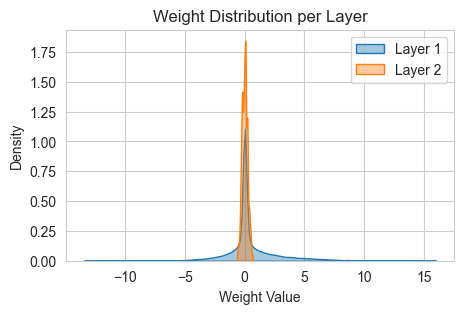

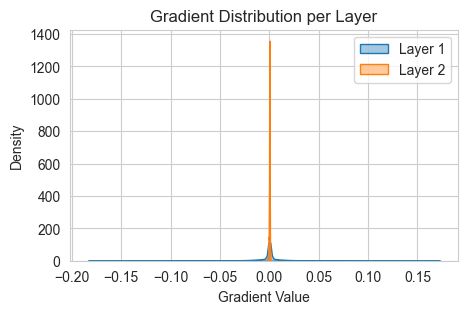

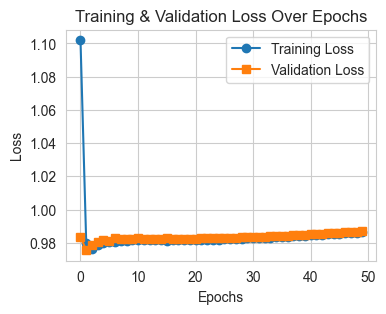

In [167]:
rmsnorm_model = FFNN([784,64,10], ['relu','softmax'], loss_function='cce', use_rmsnorm=True, weight_init='he')

rmsnorm_history = rmsnorm_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.005, verbose=0)
lr_val_pred = rmsnorm_model.predict(X_val)
lr_test_pred = rmsnorm_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

rmsnorm_model.plot_distribution([0,1,2,3], plot_type="weight")
rmsnorm_model.plot_distribution([0,1,2,3], plot_type="gradient")
rmsnorm_model.plot_loss_history(rmsnorm_history)

rmsnorm_model.save('./models/rmsnorm.json')


Val accuracy: 90.69%, Test accuracy: 93.52%


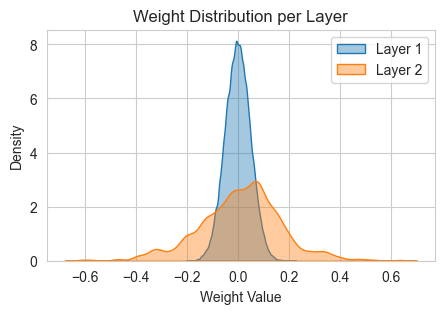

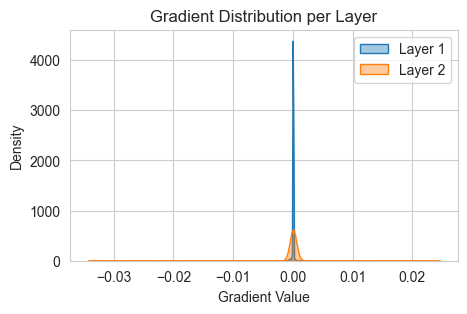

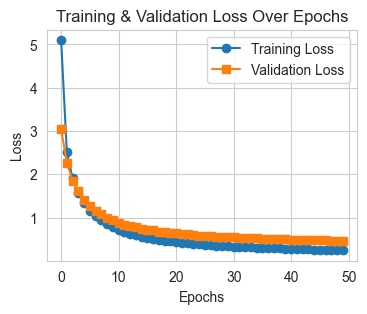

In [168]:
normsnorm_model = FFNN([784,64,10], ['relu','softmax'], loss_function='cce', use_rmsnorm=False, weight_init='he')

normsnorm_history = normsnorm_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.005, verbose=0)
lr_val_pred = normsnorm_model.predict(X_val)
lr_test_pred = normsnorm_model.predict(X_test)
y_val_labels = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(lr_val_pred, y_val_labels)
test_accuracy = accuracy_score(lr_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

normsnorm_model.plot_distribution([0,1,2,3], plot_type="weight")
normsnorm_model.plot_distribution([0,1,2,3], plot_type="gradient")
normsnorm_model.plot_loss_history(normsnorm_history)

normsnorm_model.save('./models/normsnorm.json')


### Comparison with MLPClassifier

#### Loading the data 

In [ ]:
from MNIST784Preprocessor import MNIST784Preprocessor
from sklearn.neural_network import MLPClassifier
import numpy as np
import pandas as pd

In [6]:
preprocessor = MNIST784Preprocessor(normalize="minmax")  
preprocessor.load_and_preprocess()  
mnist_x_train, mnist_x_test, mnist_y_train, mnist_y_test = preprocessor.get_data()

#### Classify with SKLearn

In [63]:
print("X_train shape"":", mnist_x_train.shape)
print("y_train labels:", np.unique(mnist_y_train))

mlp = MLPClassifier(
    hidden_layer_sizes=(100,50),
    learning_rate_init=0.05,
    activation='relu',
    solver='sgd',
    batch_size=50,
    max_iter=20,
    verbose=True,
)

mlp_history = mlp.fit(mnist_x_train,mnist_y_train)

mlp_pred = mlp.predict(mnist_x_test)

mlp_acc = accuracy_score(mnist_y_test, mlp_pred)

print(f"MLPClassifier Accuracy: {mlp_acc * 100:.2f}%")

X_train shape: (56000, 784)
y_train labels: [0 1 2 3 4 5 6 7 8 9]
Iteration 1, loss = 0.24098725
Iteration 2, loss = 0.11646914
Iteration 3, loss = 0.08964604
Iteration 4, loss = 0.07053522
Iteration 5, loss = 0.05965233
Iteration 6, loss = 0.05181579
Iteration 7, loss = 0.04842000
Iteration 8, loss = 0.04142419
Iteration 9, loss = 0.03636071
Iteration 10, loss = 0.03293809
Iteration 11, loss = 0.03075461
Iteration 12, loss = 0.02927559
Iteration 13, loss = 0.03093921
Iteration 14, loss = 0.02555625
Iteration 15, loss = 0.03010264
Iteration 16, loss = 0.02976373
Iteration 17, loss = 0.02805846
Iteration 18, loss = 0.02817238
Iteration 19, loss = 0.02655468
Iteration 20, loss = 0.02209525
MLPClassifier Accuracy: 97.53%


/Users/kaylanamira/Developer/IF3270_Tubes1_K30/src/.venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


### Classify with Miawlentera

In [41]:
encoder = OneHotEncoder(sparse_output=False) 
y_one_hot = encoder.fit_transform(mnist_y_train.reshape(-1, 1))
y_test_one_hot = encoder.transform(mnist_y_test.reshape(-1, 1))

print("x_train:", mnist_x_train.shape)
print("y_train:", y_one_hot.shape)
print("x_test:", mnist_x_test.shape)
print("y_test:", y_test_one_hot.shape)


x_train: (56000, 784)
y_train: (56000, 10)
x_test: (14000, 784)
y_test: (14000, 10)


In [60]:
miawlenteraModel = FFNN(
    layer_sizes=[784, 100, 50, 10], 
    activations=['relu', 'relu', 'softmax'],
    loss_function='cce',
    weight_init='xavier',
    use_rmsnorm=False,
    reg_type='l2',
)
history = miawlenteraModel.fit(
    mnist_x_train, y_one_hot,             
    mnist_x_test, y_test_one_hot,        
    epochs=20, batch_size=50, lr=0.05, verbose=1
)

Epoch 1/20: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 91303.65it/s]


Epoch 1 Completed - Train Loss: 2.0832 - Val Loss: 1.8257


Epoch 2/20: 100%|██████████████████████████████████████████| 56000/56000 [00:00<00:00, 96322.92it/s]


Epoch 2 Completed - Train Loss: 1.5245 - Val Loss: 1.2333


Epoch 3/20: 100%|█████████████████████████████████████████| 56000/56000 [00:00<00:00, 108460.47it/s]


...

Epoch 18 Completed - Train Loss: 0.3241 - Val Loss: 0.3264


Epoch 19/20: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 102662.05it/s]


Epoch 19 Completed - Train Loss: 0.3181 - Val Loss: 0.3211


Epoch 20/20: 100%|████████████████████████████████████████| 56000/56000 [00:00<00:00, 105546.43it/s]

Epoch 20 Completed - Train Loss: 0.3126 - Val Loss: 0.3169


In [62]:
miaw_pred = miawlenteraModel.predict(mnist_x_test)
# preds_labels = np.argmax(miaw_pred, axis=1)
miaw_accuracy = accuracy_score(miaw_pred, mnist_y_test)
# preds_labels = np.argmax(miaw_pred, axis=1)
print(f"MiawLentera Accuracy: {miaw_accuracy * 100:.2f}%")

MiawLentera Accuracy: 90.68%


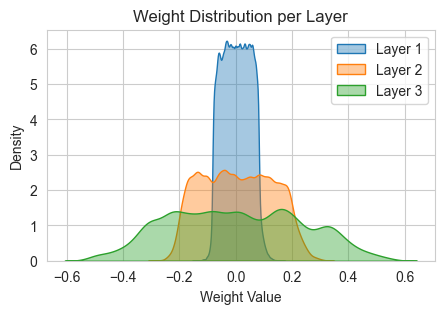

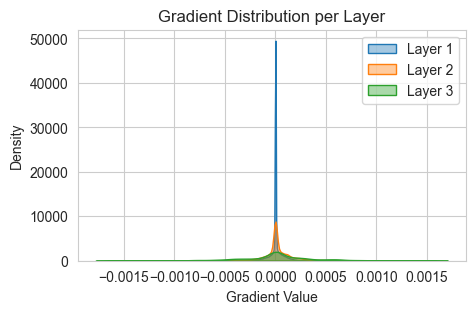

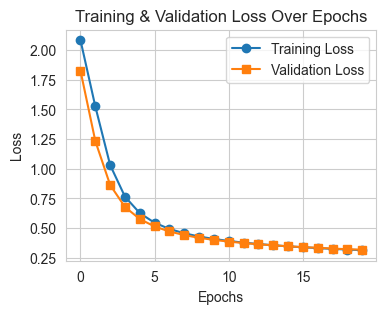

In [66]:
miawlenteraModel.plot_distribution([0,1,2,3], plot_type="weight")
miawlenteraModel.plot_distribution([0,1,2,3], plot_type="gradient")
miawlenteraModel.plot_loss_history(history)

#### Loss Comparison between 2 Models

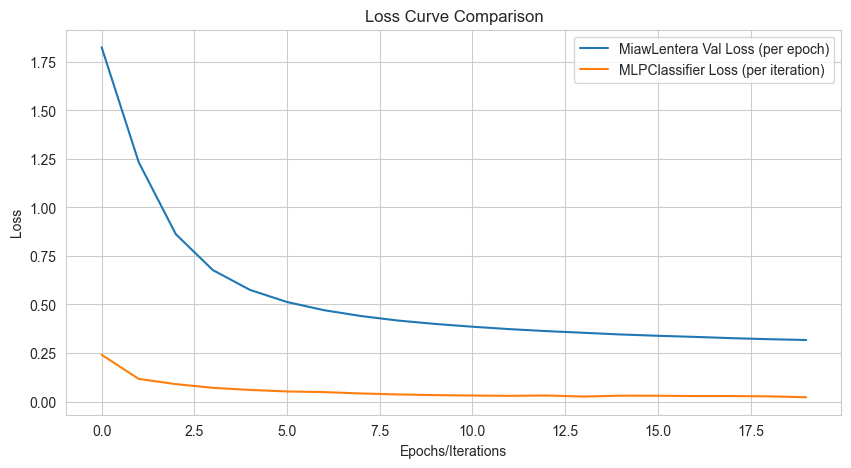

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history['val_loss'], label='MiawLentera Val Loss (per epoch)')
plt.plot(mlp.loss_curve_, label='MLPClassifier Loss (per iteration)')
plt.title('Loss Curve Comparison')
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

MiawLentera val loss (per epoch) starts around 1.8 and gradually decreases to about 0.32. The Slope is steeper in early epochs (rapid learning), but it plateaus in later epochs indicating diminishing returns from additional training. This kind of curve is expected in our custom models, it shows that it's learning, but not as fast or as deeply optimized as sklearn's MLP.

MLPClassifier Loss (per iteration) starts much lower (around 0.24), and quickly dips to below 0.05 by iteration 20. The loss flattens very quickly which show faster convergence. This likely due to internal optimizations in MLPClassifier.